In [1]:
options(scipen=999)
pacman::p_load(plyr,dplyr, stringr, data.table, tidyr,
               pheatmap, colorRamps, gridExtra, ggplot2, ggrepel, RColorBrewer,ComplexHeatmap,vioplot,ggforce,
              gridExtra, ggplot2, ggrepel, RColorBrewer,ComplexHeatmap,vioplot,grid, patchwork, grid, ggh4x)


## Directories

In [2]:
# Set working directories
base.dir =  "/nfs/lab/projects/CellCrosstalk/npod.pancreas/Final/"
assets.dir = paste(base.dir, "Assets/", sep = "") 
results.dir = paste(base.dir, "Results/corrected/", sep = "")
permutation.result.dir = paste(base.dir, "Results/corrected.permutation.test/", sep = "")


# Databases
cc.db = "/nfs/lab/projects/islet_multiomics_stress/analysis/CellChat/Assets/CellChatDB.human.txt"
Gaulton.db.dir = "/nfs/lab/Luca/Assets/LR.Database/GaultonDB_V2.txt"

permutations.test.tmp.dir = paste(permutation.result.dir, "TMP/", sep = "")
permutations.test.res.dir = paste(permutation.result.dir, "Results/", sep = "")

cc.db = "/nfs/lab/projects/islet_multiomics_stress/analysis/CellChat/Assets/CellChatDB.human.txt"

## Variables

In [3]:
# conditions
condition.ls = c("ND", "Aab", "T1D_early","T1D_late")

colors.conditions = c("ND" = "#85EF1B",
                      "Aab" = "#EFEF1B",
                      "T1D_early" = "#EF851B",
                      "T1D_late" = "#EF1B1B")

# Contrasts
Contrast_1 = c(condition.ls[2], condition.ls[3], condition.ls[4])
Contrast_2 = c(condition.ls[1], condition.ls[1], condition.ls[1])

# Celltypes and compartments
Endocrine = c('Alpha', 'Beta', 'Delta')
Exocrine = c('Acinar1_2_6','Acinar_3','Acinar_4','Acinar_5','Ductal','MUC5b_Ductal')
Immune = c('Tcells','Macrophage')
Endothelial = c('Endothelial')
Stromal = c('Activated_Stellate','Quiescent_Stellate')

cell.pop.order = c(Endocrine, Exocrine, Immune, Endothelial, Stromal)
rev.cell.pop.order = c(rev(Stromal), rev(Endothelial), rev(Immune), rev(Exocrine), rev(Endocrine), use.names = TRUE)

compartment = cell.pop.order
compartment = ifelse(compartment  %in%  Endocrine, "Endocrine", 
                 ifelse(compartment  %in%  Exocrine, "Exocrine",
                        ifelse(compartment  %in%  Immune, "Immune",
                               ifelse(compartment  %in%  Endothelial, "Endothelial", "Stromal"))))

Cellpop.compartment = as.data.frame(cbind(cell.pop.order, compartment))
Cellpop.compartment$compartment = factor(Cellpop.compartment$compartment, levels = c('Endocrine','Exocrine','Immune','Endothelial', "Stromal"))
colnames(Cellpop.compartment)[1] = "Celltype"

colors.compartments = c('Endocrine'='#26bfbf',
           'Exocrine'='#ed872d',
           'Immune'='#3F98E0',
           'Endothelial'='#800080',
           'Stromal'='#F5DE6C')

Cellpop.compartment$colors.compartments = compartment
Cellpop.compartment$colors.compartments = mapvalues(Cellpop.compartment$colors.compartments, names(colors.compartments), colors.compartments, warn_missing = TRUE)
gaps.compartments = c(3, 9, 11, 12)

# Permutation test

## Observations

In [4]:
LR.data.consensus.sig.thresh = read.table(paste(results.dir,
                                               "LR.data.consensus.sig.thresh.txt", sep = ""),
                                          sep = "\t", stringsAsFactors = F, header = T)
LR.data.consensus.sig.thresh = LR.data.consensus.sig.thresh[LR.data.consensus.sig.thresh$target %in% cell.pop.order, ]
LR.data.consensus.sig.thresh = LR.data.consensus.sig.thresh[LR.data.consensus.sig.thresh$source %in% cell.pop.order, ]

In [5]:
# Split LR pairs
LR.data.ND = LR.data.consensus.sig.thresh[LR.data.consensus.sig.thresh$condition == condition.ls[1], ]
LR.data.AAB = LR.data.consensus.sig.thresh[LR.data.consensus.sig.thresh$condition == condition.ls[2], ]
LR.data.ETD = LR.data.consensus.sig.thresh[LR.data.consensus.sig.thresh$condition == condition.ls[3], ]
LR.data.LTD = LR.data.consensus.sig.thresh[LR.data.consensus.sig.thresh$condition == condition.ls[4], ]
nrow(LR.data.consensus.sig.thresh)
# Print stats
message("LR pairs in ND: ", nrow(LR.data.ND))
message("LR pairs in AAB : ", nrow(LR.data.AAB))
message("LR pairs in Early T1D: ", nrow(LR.data.ETD))
message("LR pairs in Late T1D: ", nrow(LR.data.LTD))

[1] 87650

LR pairs in ND: 27139

LR pairs in AAB : 27459

LR pairs in Early T1D: 18179

LR pairs in Late T1D: 14873



In [6]:
head(LR.data.consensus.sig.thresh, n=1)

,ligand,source,target,receptor,prob,pval,interaction_name,interaction_name_2,pathway_name,annotation,⋯,FDR,interaction.id,compartment.source,compartment.target,Type,Mode.of.Action,Signaling,Functional.classification,Functional.sub.classification,Gene.Family
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,ADCYAP1,Beta,Quiescent_Stellate,ADCYAP1R1,0.00006164112,0.0001,ADCYAP1_ADCYAP1R1,ADCYAP1 - ADCYAP1R1,PACAP,Secreted Signaling,⋯,0.000153715,Beta--Quiescent_Stellate--ADCYAP1--ADCYAP1R1,Endocrine,Stromal,Ligand,Secreted Signaling,Hormones & Neuropeptides,Hormone/Neuropeptide,Other,PACAP Family


In [7]:
condition.sizes = c(nrow(LR.data.ND), nrow(LR.data.AAB), nrow(LR.data.ETD), nrow(LR.data.LTD))
condition.sizes

condition.size_1 = c(condition.sizes[2], condition.sizes[3], condition.sizes[4])
condition.size_2 = c(condition.sizes[1], condition.sizes[1], condition.sizes[1])

[1] 27139 27459 18179 14873

In [8]:
nsim = 100

In [9]:
# Create a named vector that maps conditions to sizes
condition_mapping <- c("ND" = condition.sizes[1], "Aab" = condition.sizes[2],
                       "T1D_early" = condition.sizes[3], "T1D_late" = condition.sizes[4])

In [10]:
LR.data.consensus.use = LR.data.consensus.sig.thresh
nrow(LR.data.consensus.use)

[1] 87650

In [11]:
head(LR.data.consensus.use[c(1,2,3,12,14,5,15,16)], n = 2)

,ligand,source,target,condition,interaction.id,prob,compartment.source,compartment.target
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>
1,ADCYAP1,Beta,Quiescent_Stellate,Aab,Beta--Quiescent_Stellate--ADCYAP1--ADCYAP1R1,0.00006164112,Endocrine,Stromal
2,ADCYAP1,Beta,Activated_Stellate,Aab,Beta--Activated_Stellate--ADCYAP1--ADCYAP1R1,0.00022605242,Endocrine,Stromal


In [12]:
# Perform the aggregation
aggregated_data <- aggregate(prob ~ ligand + source + target + condition + compartment.source + compartment.target + Signaling + Functional.classification, LR.data.consensus.sig.thresh, sum)
# normalize by condition size
aggregated_data <- aggregated_data %>%
  dplyr::mutate(prob.norm = prob / condition_mapping[as.character(condition)]) %>%
  dplyr::mutate(condition.size = condition_mapping[as.character(condition)])
aggregated_data$compartment.source = factor(aggregated_data$compartment.source, levels = unique(compartment))
aggregated_data$compartment.target = factor(aggregated_data$compartment.target, levels = unique(compartment))
aggregated_data$ligand.source.target = paste(aggregated_data$ligand, aggregated_data$source, aggregated_data$target, sep = "--")

In [13]:
head(filter(aggregated_data, condition == "ND"))

,ligand,source,target,condition,compartment.source,compartment.target,Signaling,Functional.classification,prob,prob.norm,condition.size,ligand.source.target
,<chr>,<chr>,<chr>,<chr>,<fct>,<fct>,<chr>,<chr>,<dbl>,<dbl>,<int>,<chr>
1,ANGPT2,Delta,Alpha,ND,Endocrine,Endocrine,Growth Factors & Cytokines,Angiopoietins,0.00010710204,0.0000000039464256,27139,ANGPT2--Delta--Alpha
2,ANGPT2,Delta,Beta,ND,Endocrine,Endocrine,Growth Factors & Cytokines,Angiopoietins,0.00002718320,0.0000000010016287,27139,ANGPT2--Delta--Beta
3,ANGPT2,Endothelial,Alpha,ND,Endothelial,Endocrine,Growth Factors & Cytokines,Angiopoietins,0.00014832005,0.0000000054651994,27139,ANGPT2--Endothelial--Alpha
4,ANGPTL2,Endothelial,Alpha,ND,Endothelial,Endocrine,Growth Factors & Cytokines,Angiopoietins,0.00005636900,0.0000000020770479,27139,ANGPTL2--Endothelial--Alpha
5,ANGPT2,Endothelial,Beta,ND,Endothelial,Endocrine,Growth Factors & Cytokines,Angiopoietins,0.00003764576,0.0000000013871461,27139,ANGPT2--Endothelial--Beta
6,ANGPT2,Endothelial,Delta,ND,Endothelial,Endocrine,Growth Factors & Cytokines,Angiopoietins,0.00002135209,0.0000000007867676,27139,ANGPT2--Endothelial--Delta


In [14]:
diff.obs = list()
abs.diff.obs = list()
obs.interaction.consensus = list()

for (i in seq_along(Contrast_1)){
    LR.data.use <- aggregated_data
    # Subset for the contrast
    contrast = c(Contrast_1[i], Contrast_2[i])
    # Create consensus
    interaction.consensus = filter(aggregated_data, condition %in% contrast) %>%
        select(ligand.source.target) %>%
        dplyr::distinct()
    obs.interaction.consensus[[i]] = interaction.consensus
    message("Processing ", Contrast_1[i], " vs ", Contrast_2[i])
    LR.data.c1 = LR.data.use[LR.data.use$condition %in% contrast[1], ]
    LR.data.c2 = LR.data.use[LR.data.use$condition %in% contrast[2], ]
    message("Distribution of interactions in contrast: \n",
            Contrast_1[i], ": ", nrow(LR.data.c1), "\n",
            Contrast_2[i], ": ", nrow(LR.data.c2))
    # Complete dataset
    LR.data.c1 = merge(LR.data.c1, interaction.consensus, by = "ligand.source.target", all.y = TRUE)
    LR.data.c2 = merge(LR.data.c2, interaction.consensus, by = "ligand.source.target", all.y = TRUE)
    # Replace NA with 0
    LR.data.c1$prob.norm[is.na(LR.data.c1$prob.norm)] = 0
    LR.data.c2$prob.norm[is.na(LR.data.c2$prob.norm)] = 0 
    message("Distribution of interactions in contrast - Number should be the same - : \n",
            Contrast_1[i], ": ", nrow(LR.data.c1), "\n",
            Contrast_2[i], ": ", nrow(LR.data.c2))
    # Order 
    LR.data.c1 = arrange(LR.data.c1, ligand.source.target)
    LR.data.c2 = arrange(LR.data.c2, ligand.source.target)
    message("Are Dataframe ordered in the same way? ", identical(LR.data.c1$ligand.source.target, LR.data.c2$ligand.source.target))
    # Compute difference
    diff = LR.data.c1$prob.norm - LR.data.c2$prob.norm
    diff.obs[[i]] = data.frame(ligand.source.target = LR.data.c1$ligand.source.target, condition = contrast[1],
                              diff = diff, abs.diff = abs(diff))
}

Processing Aab vs ND

Distribution of interactions in contrast: 
Aab: 8801
ND: 8500

Distribution of interactions in contrast - Number should be the same - : 
Aab: 9739
ND: 9739

Are Dataframe ordered in the same way? TRUE

Processing T1D_early vs ND

Distribution of interactions in contrast: 
T1D_early: 6390
ND: 8500

Distribution of interactions in contrast - Number should be the same - : 
T1D_early: 9233
ND: 9233

Are Dataframe ordered in the same way? TRUE

Processing T1D_late vs ND

Distribution of interactions in contrast: 
T1D_late: 5069
ND: 8500

Distribution of interactions in contrast - Number should be the same - : 
T1D_late: 9024
ND: 9024

Are Dataframe ordered in the same way? TRUE



## Simulations

In [15]:
setwd(permutations.test.tmp.dir)
sim.list <- dir(pattern = "_DFnet.txt")

In [319]:
# Create tables to fill up
diff.sim = list()
random.success.table = list()
# Create tables with correct number of rows
random.success.table[[1]] = data.frame(ligand.source.target = obs.interaction.consensus[[1]])
random.success.table[[2]] = data.frame(ligand.source.target = obs.interaction.consensus[[2]])
random.success.table[[3]] = data.frame(ligand.source.target =obs.interaction.consensus[[3]])

for (s.i in seq_along(sim.list)){
        # Get files
        print(paste0("Processing: ", sim.list[s.i]))
        # Load simulation data
        LR.data.use <- read.table(sim.list[s.i], sep = "\t", stringsAsFactors = F, header = T)
        # Create a named vector that maps conditions to sizes
        condition.sim_mapping <- c("ND" = nrow(LR.data.use[LR.data.use$condition == "ND",]),
                               "Aab" = nrow(LR.data.use[LR.data.use$condition == "Aab",]),          
                               "T1D_early" = nrow(LR.data.use[LR.data.use$condition == "T1D_early",]),           
                               "T1D_late" = nrow(LR.data.use[LR.data.use$condition == "T1D_late",]))
        message("\t Detected: ", nrow(LR.data.use), " interactions")
        message(" Normalizing ND: ", condition.sim_mapping[1],
                "\n Normalizing AAB: ", condition.sim_mapping[2],
                "\n Normalizing ETD: ", condition.sim_mapping[3],
                "\n Normalizing LTD: ", condition.sim_mapping[4]
               )        
        # Perform the aggregation
        aggregated_data.sim <- aggregate(prob ~ ligand + source + target + condition, LR.data.use, sum)
        # normalize by condition size
        aggregated_data.sim <- aggregated_data.sim %>%
          dplyr::mutate(prob.norm = prob / condition.sim_mapping[as.character(condition)]) %>%
          dplyr::mutate(condition.size = condition_mapping[as.character(condition)])
        aggregated_data.sim$ligand.source.target = paste(aggregated_data.sim$ligand, aggregated_data.sim$source, aggregated_data.sim$target, sep = "--")
        for (i in seq_along(Contrast_1)){
                        # Subset for the contrast
                        contrast = c(Contrast_1[i], Contrast_2[i])
                        message("Processing ", Contrast_1[i], " vs ", Contrast_2[i])
                        # Use consensus of the observations to compare the same ligands
                        interaction.consensus = obs.interaction.consensus[[i]]
                        LR.data.c1 = aggregated_data.sim[aggregated_data.sim$condition %in% contrast[1], ]
                        LR.data.c2 = aggregated_data.sim[aggregated_data.sim$condition %in% contrast[2], ]
                        message("Distribution of interactions in contrast: \n",
                                Contrast_1[i], ": ", nrow(LR.data.c1), "\n",
                                Contrast_2[i], ": ", nrow(LR.data.c2))
                        # Complete dataset
                        LR.data.c1 = merge(LR.data.c1, interaction.consensus, by = "ligand.source.target", all.y = TRUE)
                        LR.data.c2 = merge(LR.data.c2, interaction.consensus, by = "ligand.source.target", all.y = TRUE)
                        # Replace NA with 0
                        LR.data.c1$prob.norm[is.na(LR.data.c1$prob.norm)] = 0
                        LR.data.c2$prob.norm[is.na(LR.data.c2$prob.norm)] = 0 
                        message("Distribution of interactions in contrast - Number should be the same - : \n",
                                Contrast_1[i], ": ", nrow(LR.data.c1), "\n",
                                Contrast_2[i], ": ", nrow(LR.data.c2))
                        # Order 
                        LR.data.c1 = arrange(LR.data.c1, ligand.source.target)
                        LR.data.c2 = arrange(LR.data.c2, ligand.source.target)
                        message("Are Dataframe ordered in the same way? ", identical(LR.data.c1$ligand.source.target, LR.data.c2$ligand.source.target))
                        # Compute difference
                        diff = LR.data.c1$prob.norm - LR.data.c2$prob.norm
                        diff.sim[[i]] = data.frame(ligand.source.target = LR.data.c1$ligand.source.target, condition = contrast[1],
                                        diff = diff, abs.diff = abs(diff))
                        random.success = diff.sim[[i]]$abs.diff > diff.obs[[i]]$abs.diff
                        random.success.table[[i]] = cbind(random.success.table[[i]], random.success)
                        colnames(random.success.table[[i]])[ncol(random.success.table[[i]])] = s.i  
                }
}

[1] "Processing: CellChat_Permutation_n1_DFnet.txt"


	 Detected: 99555 interactions

 Normalizing ND: 22024
 Normalizing AAB: 27464
 Normalizing ETD: 26560
 Normalizing LTD: 23507

Processing Aab vs ND

Distribution of interactions in contrast: 
Aab: 8876
ND: 7437

Distribution of interactions in contrast - Number should be the same - : 
Aab: 9739
ND: 9739

Are Dataframe ordered in the same way? TRUE

Processing T1D_early vs ND

Distribution of interactions in contrast: 
T1D_early: 8701
ND: 7437

Distribution of interactions in contrast - Number should be the same - : 
T1D_early: 9233
ND: 9233

Are Dataframe ordered in the same way? TRUE

Processing T1D_late vs ND

Distribution of interactions in contrast: 
T1D_late: 7917
ND: 7437

Distribution of interactions in contrast - Number should be the same - : 
T1D_late: 9024
ND: 9024

Are Dataframe ordered in the same way? TRUE



[1] "Processing: CellChat_Permutation_n10_DFnet.txt"


	 Detected: 100481 interactions

 Normalizing ND: 27308
 Normalizing AAB: 25931
 Normalizing ETD: 23769
 Normalizing LTD: 23473

Processing Aab vs ND

Distribution of interactions in contrast: 
Aab: 8597
ND: 8662

Distribution of interactions in contrast - Number should be the same - : 
Aab: 9739
ND: 9739

Are Dataframe ordered in the same way? TRUE

Processing T1D_early vs ND

Distribution of interactions in contrast: 
T1D_early: 8130
ND: 8662

Distribution of interactions in contrast - Number should be the same - : 
T1D_early: 9233
ND: 9233

Are Dataframe ordered in the same way? TRUE

Processing T1D_late vs ND

Distribution of interactions in contrast: 
T1D_late: 7866
ND: 8662

Distribution of interactions in contrast - Number should be the same - : 
T1D_late: 9024
ND: 9024

Are Dataframe ordered in the same way? TRUE



[1] "Processing: CellChat_Permutation_n100_DFnet.txt"


...

	 Detected: 100999 interactions

 Normalizing ND: 25650
 Normalizing AAB: 26576
 Normalizing ETD: 25895
 Normalizing LTD: 22878

Processing Aab vs ND

Distribution of interactions in contrast: 
Aab: 8485
ND: 8457

Distribution of interactions in contrast - Number should be the same - : 
Aab: 9739
ND: 9739

Are Dataframe ordered in the same way? TRUE

Processing T1D_early vs ND

Distribution of interactions in contrast: 
T1D_early: 8532
ND: 8457

Distribution of interactions in contrast - Number should be the same - : 
T1D_early: 9233
ND: 9233

Are Dataframe ordered in the same way? TRUE

Processing T1D_late vs ND

Distribution of interactions in contrast: 
T1D_late: 7879
ND: 8457

Distribution of interactions in contrast - Number should be the same - : 
T1D_late: 9024
ND: 9024

Are Dataframe ordered in the same way? TRUE



[1] "Processing: CellChat_Permutation_n98_DFnet.txt"


	 Detected: 99113 interactions

 Normalizing ND: 27409
 Normalizing AAB: 24931
 Normalizing ETD: 22034
 Normalizing LTD: 24739

Processing Aab vs ND

Distribution of interactions in contrast: 
Aab: 8088
ND: 8884

Distribution of interactions in contrast - Number should be the same - : 
Aab: 9739
ND: 9739

Are Dataframe ordered in the same way? TRUE

Processing T1D_early vs ND

Distribution of interactions in contrast: 
T1D_early: 7276
ND: 8884

Distribution of interactions in contrast - Number should be the same - : 
T1D_early: 9233
ND: 9233

Are Dataframe ordered in the same way? TRUE

Processing T1D_late vs ND

Distribution of interactions in contrast: 
T1D_late: 8272
ND: 8884

Distribution of interactions in contrast - Number should be the same - : 
T1D_late: 9024
ND: 9024

Are Dataframe ordered in the same way? TRUE



[1] "Processing: CellChat_Permutation_n99_DFnet.txt"


	 Detected: 100786 interactions

 Normalizing ND: 28311
 Normalizing AAB: 24313
 Normalizing ETD: 24495
 Normalizing LTD: 23667

Processing Aab vs ND

Distribution of interactions in contrast: 
Aab: 8047
ND: 9207

Distribution of interactions in contrast - Number should be the same - : 
Aab: 9739
ND: 9739

Are Dataframe ordered in the same way? TRUE

Processing T1D_early vs ND

Distribution of interactions in contrast: 
T1D_early: 8007
ND: 9207

Distribution of interactions in contrast - Number should be the same - : 
T1D_early: 9233
ND: 9233

Are Dataframe ordered in the same way? TRUE

Processing T1D_late vs ND

Distribution of interactions in contrast: 
T1D_late: 7946
ND: 9207

Distribution of interactions in contrast - Number should be the same - : 
T1D_late: 9024
ND: 9024

Are Dataframe ordered in the same way? TRUE



In [320]:
# Wrap up test results
for (i in seq_along(diff.obs)){
    message("Processing contrast #", i)
    diff.obs[[i]]$random.success = rowSums(random.success.table[[i]] == "TRUE", na.rm = TRUE)
    diff.obs[[i]]$pvalue = diff.obs[[i]]$random.success/nsim
    # correct pvalues of what had no difference to begin with
    diff.obs[[i]]$pvalue = replace(diff.obs[[i]]$pvalue, diff.obs[[i]]$diff == 0, 1)
    # calculate FDR
    diff.obs[[i]]$pvalue[diff.obs[[i]]$pvalue == 0] = 0.0001
    diff.obs[[i]]$FDR = p.adjust(diff.obs[[i]]$pvalue, 'BH')
    # counting stars
    diff.obs[[i]]$stars = diff.obs[[i]]$FDR
    diff.obs[[i]]$stars[diff.obs[[i]]$FDR > 0.1]<-""
    diff.obs[[i]]$stars[diff.obs[[i]]$FDR < 0.1]<-"*"
    diff.obs[[i]]$stars[diff.obs[[i]]$FDR < 0.05]<-"**"
    diff.obs[[i]]$stars[diff.obs[[i]]$FDR < 0.01]<-"***"
    file.name = paste(permutations.test.res.dir, "Permutation.test_cellpairs_ligand.FDR.", Contrast_1[i], ".res", sep = "")
    write.table(diff.obs[[i]], file.name, sep = "\t", quote = F, col.names=T, row.names = T) 
}

Processing contrast #1

Processing contrast #2

Processing contrast #3



In [321]:
test = filter(diff.obs[[2]], pvalue < 0.05)
nrow(test)
test = filter(diff.obs[[2]], FDR < 0.1)
nrow(test)

[1] 1599

[1] 1017

In [16]:
cell.pairs.ligand = NULL
setwd(permutations.test.res.dir)

for (i in dir(pattern = "Permutation.test_cellpairs_ligand")){
    message(i)
    data.use = read.table(i, sep = "\t")
    cell.pairs.ligand = rbind(cell.pairs.ligand, data.use)
}

Permutation.test_cellpairs_ligand.FDR.Aab.res

Permutation.test_cellpairs_ligand.FDR.T1D_early.res

Permutation.test_cellpairs_ligand.FDR.T1D_late.res



In [17]:
# Load and prepare Gaulton DB
Gaulton.db.dir = "/nfs/lab/Luca/Assets/LR.Database/GaultonDB_V3.txt"
gaulton.db.data = read.table(Gaulton.db.dir, sep = "\t", stringsAsFactors = F, header = T)
colnames(gaulton.db.data)[1] = "ligand"

Functional.classification.order = c("Hormones & Neuropeptides", "Enzymatic", 
                                            "Immune", "Growth Factors & Cytokines", "Developmental",
                                            "CAM", "ECM")

In [18]:
cell.pairs.ligand$ligand = str_split_fixed(cell.pairs.ligand$ligand.source.target, pattern = "--", n = 3)[,1]
cell.pairs.ligand$source = str_split_fixed(cell.pairs.ligand$ligand.source.target, pattern = "--", n = 3)[,2]
cell.pairs.ligand$target = str_split_fixed(cell.pairs.ligand$ligand.source.target, pattern = "--", n = 3)[,3]
cell.pairs.ligand = merge(cell.pairs.ligand, gaulton.db.data, by = "ligand")
cell.pairs.ligand$diff = cell.pairs.ligand$diff * 10000
cell.pairs.ligand$abs.diff = cell.pairs.ligand$abs.diff * 10000
head(cell.pairs.ligand, n= 2)

,ligand,ligand.source.target,condition,diff,abs.diff,random.success,pvalue,FDR,stars,source,target,Mode.of.Action,Signaling,Functional.classification,Functional.sub.classification,Gene.Family
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,ADCYAP1,ADCYAP1--Beta--Activated_Stellate,Aab,-0.00002039875,0.00002039875,38,0.38,0.999453,NA,Beta,Activated_Stellate,Secreted Signaling,Hormones & Neuropeptides,Hormone/Neuropeptide,Other,PACAP Family
2,ADCYAP1,ADCYAP1--Beta--Quiescent_Stellate,Aab,-0.00001988201,0.00001988201,66,0.66,0.999453,NA,Beta,Quiescent_Stellate,Secreted Signaling,Hormones & Neuropeptides,Hormone/Neuropeptide,Other,PACAP Family


In [19]:
file.name = paste(permutations.test.res.dir, "Permutation.test_ALL_cellpairs_ligand.FDR.res", sep = "")
write.table(cell.pairs.ligand, file.name, sep = "\t", quote = F, col.names=T, row.names = T) 

# Plot

In [20]:
color_df <- data.frame(
  Signaling = c("Hormones & Neuropeptides", "Enzymatic", 
                "Immune", 
                "Growth Factors & Cytokines", "Developmental",
                "CAM", "ECM"),
  colors = c(
    '#4DA6FF', '#C0A2FF',  # Blue for Hormones & Neuropeptides, Darker Purple for Enzymes (Class 1)
    '#FF3300',   # Reds for immune stuff
    '#FFA64D', '#FFD700',  # Oranges to Light Yellow for Class 3
    '#8fc299', '#8F716A'  # green and brown for cell adhesion and ECM
  )
)

# Create a named vector from the dataframe
color_vector <- setNames(color_df$colors, color_df$Signaling)

In [21]:
color_vector

Hormones & Neuropeptides                  Enzymatic 
                 "#4DA6FF"                  "#C0A2FF" 
                    Immune Growth Factors & Cytokines 
                 "#FF3300"                  "#FFA64D" 
             Developmental                        CAM 
                 "#FFD700"                  "#8fc299" 
                       ECM 
                 "#8F716A"

In [22]:
# Perform the aggregation
aggregated_data <- aggregate(prob ~ ligand + source + target + condition + compartment.source + compartment.target + Signaling, LR.data.consensus.sig.thresh, sum)
# normalize by condition size
aggregated_data <- aggregated_data %>%
  dplyr::mutate(prob.norm = prob / condition_mapping[as.character(condition)]) %>%
  dplyr::mutate(condition.size = condition_mapping[as.character(condition)])
# Factorize
aggregated_data$y = 1
aggregated_data$compartment.source = factor(aggregated_data$compartment.source, levels = unique(compartment))
aggregated_data$compartment.target = factor(aggregated_data$compartment.target, levels = unique(compartment))
aggregated_data$condition = factor(aggregated_data$condition, levels = rev(condition.ls))
aggregated_data$ligand = as.factor(aggregated_data$ligand)
aggregated_data$source = as.factor(aggregated_data$source)
aggregated_data$target = as.factor(aggregated_data$target)
aggregated_data$condition = as.factor(aggregated_data$condition)
aggregated_data$ligand.source.target.condition = paste(aggregated_data$ligand, 
                                                       aggregated_data$source, 
                                                       aggregated_data$target, 
                                                       aggregated_data$condition,
                                                       sep = "--")
# Apply linear transformation
aggregated_data$prob.norm = aggregated_data$prob.norm * 10000
# remove useless category
aggregated_data = dplyr::filter(aggregated_data, Signaling != "Other")
aggregated_data$Signaling <- factor(aggregated_data$Signaling, levels = names(color_vector))

# Add stars
file.name = paste(permutations.test.res.dir, "Permutation.test_ALL_cellpairs_ligand.FDR.res", sep = "")
stars = read.table(file.name, sep = "\t")
stars$ligand.source.target.condition = paste(stars$ligand, 
                                                       stars$source, 
                                                       stars$target, 
                                                       stars$condition,
                                                       sep = "--")
stars = select(stars, ligand.source.target.condition, FDR, diff, abs.diff, stars)
aggregated_data = merge(aggregated_data, stars, by = "ligand.source.target.condition", all.x = TRUE)
head(aggregated_data, n = 2)

,ligand.source.target.condition,ligand,source,target,condition,compartment.source,compartment.target,Signaling,prob,prob.norm,condition.size,y,FDR,diff,abs.diff,stars
,<chr>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,ADCYAP1--Beta--Activated_Stellate--Aab,ADCYAP1,Beta,Activated_Stellate,Aab,Endocrine,Stromal,Hormones & Neuropeptides,0.0002260524,0.00008232362,27459,1,0.999453,-0.00002039875,0.00002039875,NA
2,ADCYAP1--Beta--Activated_Stellate--ND,ADCYAP1,Beta,Activated_Stellate,ND,Endocrine,Stromal,Hormones & Neuropeptides,0.0002787782,0.00010272236,27139,1,NA,NA,NA,NA


In [23]:
file.name = paste(permutations.test.res.dir, "Permutation.test_ALL_cellpairs_ligand.data.res", sep = "")
write.table(aggregated_data, file.name, sep = "\t", quote = F, col.names=T, row.names = T) 

In [24]:
# dplyr::filter(aggregated_data, ligand == "PTPRM" & condition %in% c("ND", "T1D_early"))

In [25]:
# dplyr::filter(diff.obs[[2]], ligand.source.target == "PTPRM--MUC5b_Ductal--Beta")

In [26]:
print(levels(aggregated_data$Signaling))
cell.pop.order
condition.ls

[1] "Hormones & Neuropeptides"   "Enzymatic"                 
[3] "Immune"                     "Growth Factors & Cytokines"
[5] "Developmental"              "CAM"                       
[7] "ECM"                       


[1] "Alpha"              "Beta"               "Delta"             
 [4] "Acinar1_2_6"        "Acinar_3"           "Acinar_4"          
 [7] "Acinar_5"           "Ductal"             "MUC5b_Ductal"      
[10] "Tcells"             "Macrophage"         "Endothelial"       
[13] "Activated_Stellate" "Quiescent_Stellate"

[1] "ND"        "Aab"       "T1D_early" "T1D_late"

In [75]:
cc.db.dir = "/nfs/lab/Luca/Assets/LR.Database/CellChatDB.human.txt"
CC.db = read.table(cc.db.dir, sep = "\t", stringsAsFactors = F, header = T)

In [139]:
# Fetch ligands for receptor of interest
receptor.ligands = dplyr::filter(CC.db, receptor == "ITGAV_ITGB8") %>%
                   distinct(ligand)

In [171]:
source.cell = c("Activated_Stellate")

# source.cell = c("Endothelial", "Activated_Stellate", "Quiescent_Stellate")

target.cell = "Beta"

ligands.use = receptor.ligands$ligand

# Subset for conditions
conditions.use = c("T1D_early", "ND")

#conditions.use = condition.ls

In [172]:
mat = aggregated_data %>%
    complete(ligand, source, target, condition, nesting(), fill = list(prob.norm = 0)) %>%
    filter(target %in% target.cell 
           & source %in% source.cell 
           & condition %in% conditions.use) 

In [173]:
# Identify top 10 ligands
top_ligands <- mat %>%
  dplyr::filter(ligand %in% ligands.use) %>%
  arrange(desc(abs.diff)) %>%
  distinct(ligand) %>%
  slice_head(n = 10)

mat = mat %>%
  filter(ligand %in% top_ligands$ligand)

message("this should be 10 -> ", length(top_ligands$ligand))

this should be 10 -> 10



In [174]:
max(mat$prob.norm)

[1] 0.06404044

Warning message:
“Removed 10 rows containing missing values (`geom_text()`).”


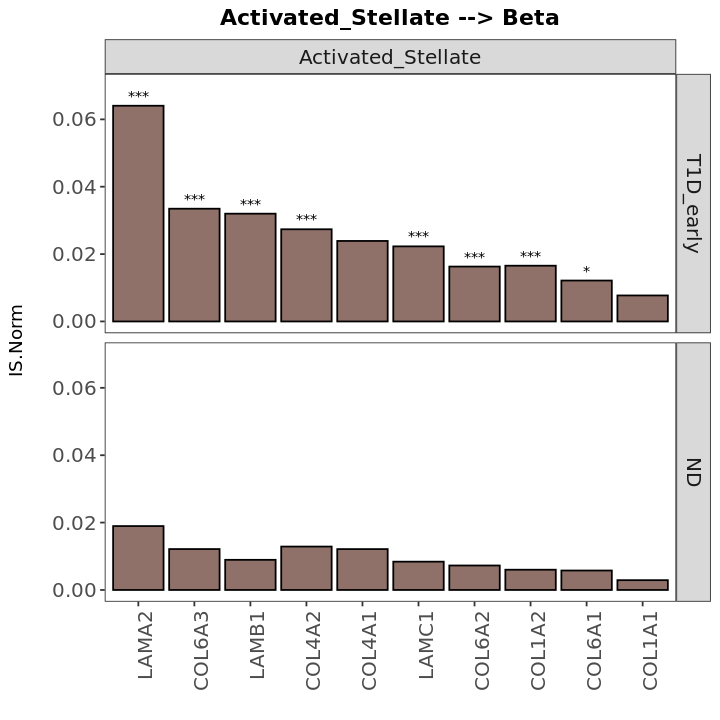

In [176]:
options(repr.plot.width=6, repr.plot.height=6)
ggplot(mat, aes(x = reorder(ligand, -prob.norm), y = prob.norm, fill = Signaling, label = stars)) +
  geom_bar(stat = "identity", position = "dodge", colour="black", linewidth = 0.5) +
  theme_bw() +
  theme(panel.grid = element_blank(),
        strip.text.x = element_text(size = 12),
        strip.text.y = element_text(size = 12),
        axis.text.x = element_text(angle = 90, hjust = 1, size = 12),
        axis.text.y = element_text(size = 12),
        plot.title = element_text(hjust = 0.5,face = "bold") ,
        legend.position = "none") + 
  labs(x = "", y = "IS.Norm \n ", fill = "Signaling", 
       title = paste0(source.cell, " --> ", target.cell)) +
  facet_nested(rows = vars(condition), 
               cols = vars(source),
               scales = "free", space = "free") +
  scale_fill_manual(values = color_vector) +
  geom_text(vjust = - 0.5, size = 3)+
  ylim(0, 0.07)

In [69]:
# Have to figure out a way to intuitively show how these interactions are going

In [485]:
# if you want the legend

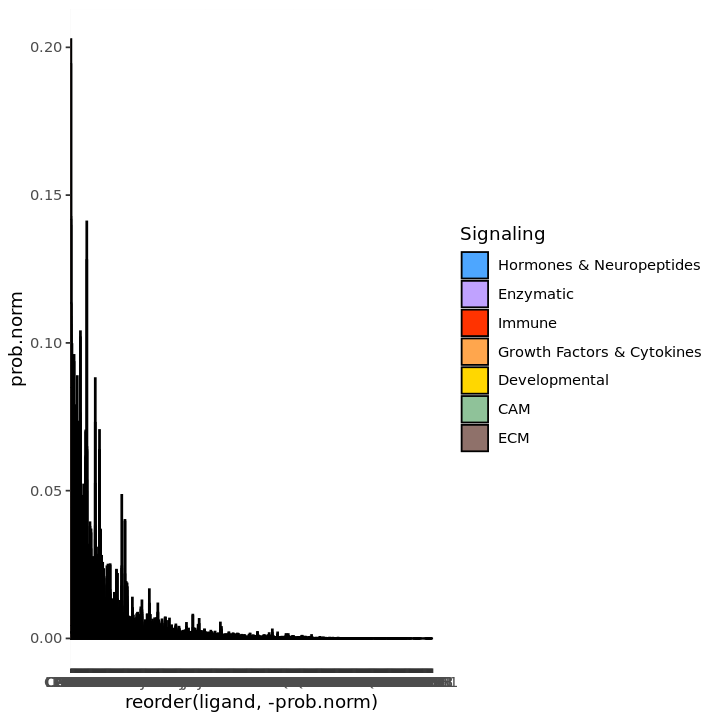

In [339]:
ggplot(aggregated_data, aes(x = reorder(ligand, -prob.norm), y = prob.norm, fill = Signaling)) +
  geom_bar(stat = "identity", position = "dodge", colour="black", linewidth = 0.5) +
  scale_fill_manual(values = color_vector)

In [340]:
# Check for specific things:
aggregated_data %>% 
          dplyr::filter(Signaling %in% "Enzymatic"
                    & source %in% "Alpha") %>% 
            distinct(ligand, .keep_all = TRUE)

ligand.source.target.condition,ligand,source,target,condition,compartment.source,compartment.target,Signaling,prob,prob.norm,condition.size,y,FDR,diff,abs.diff,stars
<chr>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
F2--Alpha--Acinar_3--Aab,F2,Alpha,Acinar_3,Aab,Endocrine,Exocrine,Enzymatic,0.00009609775,0.00003499681,27459,1,0.999453,-0.000102079237,0.000102079237,NA
PSAP--Alpha--Alpha--Aab,PSAP,Alpha,Alpha,Aab,Endocrine,Endocrine,Enzymatic,0.00003645492,0.00001327613,27459,1,0.999453,0.000003717058,0.000003717058,NA
